# Realestate Price Prediction Analysis

In [20]:
# Import Matplotlib, pandas, and plotly
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
warnings.filterwarnings("ignore")

In [21]:
df1 = pd.read_csv(r"Real estate.csv")

df1.dropna(inplace=True)
low, high = df1['Y house price of unit area'].quantile([0.1,0.9])
df1 = df1[df1['Y house price of unit area'].between(low, high)]
df1.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


# Exploratory Data Analysis

In [22]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 330 entries, 0 to 412
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      330 non-null    int64  
 1   X1 transaction date                     330 non-null    float64
 2   X2 house age                            330 non-null    float64
 3   X3 distance to the nearest MRT station  330 non-null    float64
 4   X4 number of convenience stores         330 non-null    int64  
 5   X5 latitude                             330 non-null    float64
 6   X6 longitude                            330 non-null    float64
 7   Y house price of unit area              330 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 23.2 KB


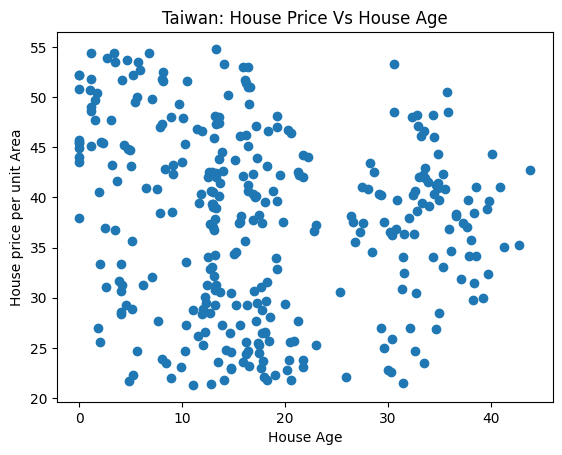

In [23]:
## Lets check the correlation between the house age and house price perunit of area
## Expected Older the house lower the price because of factors outdate functional feature, physical damage etc

plt.scatter(df1['X2 house age'],df1['Y house price of unit area'])
plt.xlabel("House Age")
plt.ylabel("House price per unit Area")
plt.title("Taiwan: House Price Vs House Age")
plt.show()

<p>The above plot does not indicate the correlation  between age of house and price

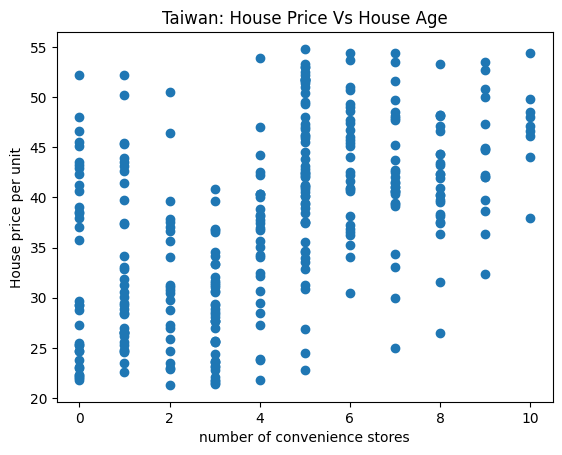

In [24]:
## Lets check the relation of price  with number of convenience stores near by
## Larger the number higher the price


plt.scatter(df1['X4 number of convenience stores'],df1['Y house price of unit area'])
plt.xlabel("number of convenience stores")
plt.ylabel("House price per unit")
plt.title("Taiwan: House Price Vs House Age")
plt.show()

<p>Correlation seems to be there as when the number of store is from 0 3 house price is clustered around 25 to 35 and when the number of store is from 5 to 10 the price is greater then 35</p>

In [25]:
df1[['X4 number of convenience stores','Y house price of unit area']].corr()

,X4 number of convenience stores,Y house price of unit area
X4 number of convenience stores,1.000000,0.505779
Y house price of unit area,0.505779,1.000000


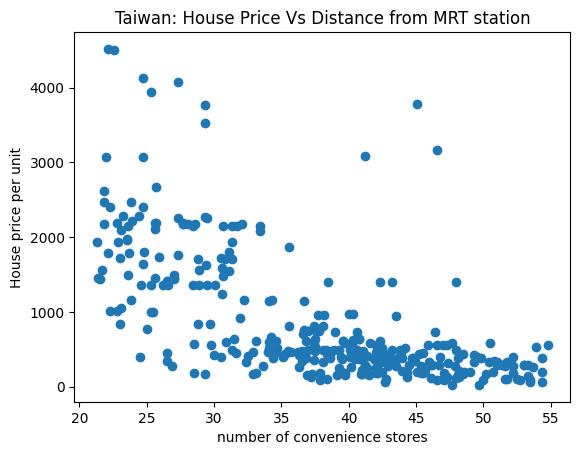

In [26]:
##Checking correlation distance to the nearest MRT station  and price
## Assumed to be higher the distance lower the price is 
plt.scatter(df1['Y house price of unit area'],df1['X3 distance to the nearest MRT station'],)
plt.xlabel("number of convenience stores")
plt.ylabel("House price per unit")
plt.title("Taiwan: House Price Vs Distance from MRT station")
plt.show()

<p>THe above plot show that  distance to the nearest MRT station and price are highly correlated</p>

In [27]:
df1[['X3 distance to the nearest MRT station','Y house price of unit area']].corr()

,X3 distance to the nearest MRT station,Y house price of unit area
X3 distance to the nearest MRT station,1.000000,-0.653311
Y house price of unit area,-0.653311,1.000000


# Model Building

### From now we will work on the following column
> X3 distance to the nearest MRT station<br>
> X4 number of convenience stores <br>
> Y house price of unit

### Model 1

In [28]:
from sklearn.linear_model import LinearRegression

## Witht the help of X4 number of convenience stores
df2 = df1.copy()
#df2 = df2[df2['X4 number of convenience stores']>0]
#df2 = df2[df2['Y house price of unit area']!=0]

#df2.dropna(inplace=True)
df2['X4 number of convenience stores']  = df2['X4 number of convenience stores'].astype(float)
df2['Y house price of unit area']  = df2['Y house price of unit area'].astype(float)
X_train = df2[['X4 number of convenience stores']].iloc[:int(len(df2)*.8)]
y_train = df2['Y house price of unit area'].iloc[:int(len(df2)*.8)]
X_test = df2[['X4 number of convenience stores']].iloc[int(len(df2)*.8):]
y_test = df2['Y house price of unit area'].iloc[int(len(df2)*.8):]


In [29]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

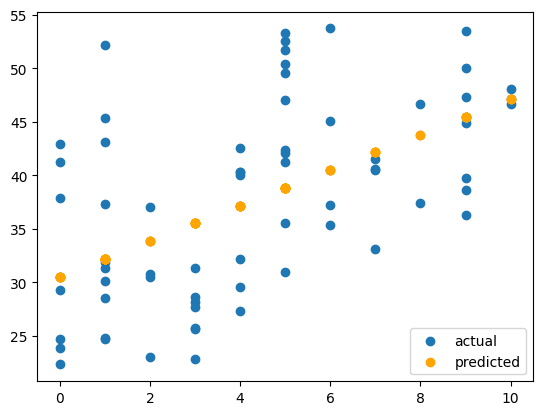

In [30]:
predicted_value = model.predict(X_test)
plt.scatter(x=X_test, y=y_test, label="actual")
plt.scatter(x=X_test, y=predicted_value,color="orange",label="predicted")
plt.legend()

Model Evaluation

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
y_pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))
print("R2:", r2_score(y_test, y_pred))

MAE: 6.327812298987678
MSE: 58.22059359849497
RMSE: 7.630242040623283
R2: 0.284830874179677


## Model 2
With distance from MRT Station Feature metrix 

In [32]:
X_train = df1[['X3 distance to the nearest MRT station']].iloc[:int(len(df1)*.8)]
X_test = df1[['X3 distance to the nearest MRT station']].iloc[int(len(df1)*.8):]
y2_train = df1['Y house price of unit area'].iloc[:int(len(df1)*.8)]
y2_test = df1['Y house price of unit area'].iloc[int(len(df1)*.8):]


In [33]:
model2 = LinearRegression()
model2.fit(X_train, y2_train)

LinearRegression()

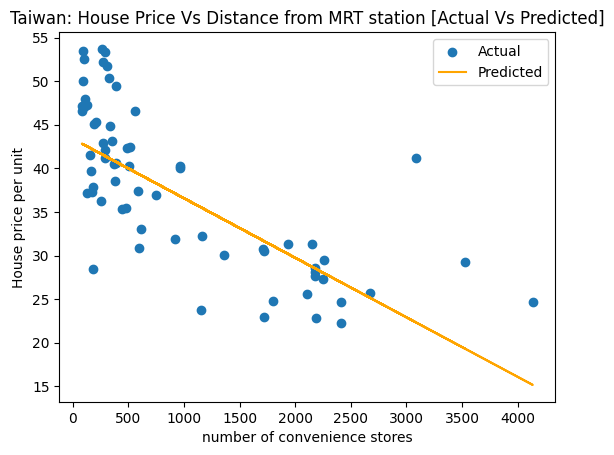

In [34]:
m2_predict = model2.predict(X_test)
plt.scatter(X_test, y2_test, label="Actual")
plt.plot(X_test, m2_predict,label="Predicted", color="orange")
plt.xlabel("number of convenience stores")
plt.ylabel("House price per unit")
plt.title("Taiwan: House Price Vs Distance from MRT station [Actual Vs Predicted]")
plt.legend()
plt.show()

Model Evaluation

In [35]:
# metrics
print("MAE:", mean_absolute_error(y2_test, m2_predict))
print("MSE:", mean_squared_error(y2_test, m2_predict))
print("RMSE:", mean_squared_error(y2_test, m2_predict, squared=False))
print("R2:", r2_score(y2_test, m2_predict))


MAE: 4.809460025573077
MSE: 38.752993201179784
RMSE: 6.225190214056096
R2: 0.523966648953488


# Score Card

In [36]:
column =  ["Distance","Store"]
data = {
    "Score":['MAE','MSE','RMSE','R2'],
    "Distance":[ mean_absolute_error(y2_test, m2_predict),mean_squared_error(y2_test, m2_predict),mean_squared_error(y2_test, m2_predict, squared=False),r2_score(y2_test, m2_predict)],
    "Store": [ mean_absolute_error(y_test, y_pred),mean_squared_error(y_test, y_pred),mean_squared_error(y_test, y_pred, squared=False),r2_score(y_test, y_pred)],
        }

score_board = pd.DataFrame(data)
score_board.set_index("Score", drop=True, inplace=True)
score_board

,Distance,Store
Score,,
MAE,4.809460,6.327812
MSE,38.752993,58.220594
RMSE,6.225190,7.630242
R2,0.523967,0.284831


### Conclusion
Based on the model comparison, we conclude that distance from the MRT station is a strong predictor of house price per unit. I recommend that clients consider distance as a key differentiator when assessing property prices.

### Appendix 
>Predicted Error: distance between actual value and predicted value.
>MAE:  measure the average predicted error <br>
>MSE: It is average of square predicted error<br>
>RMSE: Square root of MSE
